# Two-Body Weber Electrodynamics — Canonical Reference

The package's hello-world. This notebook integrates the canonical two-body Weber problem end-to-end and exercises every diagnostic plot.

The initial conditions and expected behaviour are specified — implementation-independently — in [`two_body_reference.md`](two_body_reference.md). A plain `.jl` script that reproduces every figure to `output/` lives in [`two_body_reference.jl`](two_body_reference.jl).

## Weber Hamiltonian

For $N$ charged particles,

$$H = \sum_i \frac{|\mathbf{p}_i|^2}{2m_i} + \sum_{i<j} U_{ij}, \qquad U_{ij} = \frac{q_i q_j}{r_{ij}} \left(1 - \frac{\dot{r}_{ij}^2}{2c^2}\right)$$

where $r_{ij} = |\mathbf{r}_i - \mathbf{r}_j|$ and

$$\dot{r}_{ij} = \frac{(\mathbf{r}_i - \mathbf{r}_j) \cdot (\mathbf{v}_i - \mathbf{v}_j)}{r_{ij}}$$

The velocity-dependent term produces **orbital precession** analogous to relativistic effects in general relativity.

In [1]:
using WeberElectrodynamics
using Plots
using Printf

## 1. System Construction

Create a `WeberSystem` for two particles in 2D. The system is purely symbolic - physical parameters (masses, charges, c) are specified when creating the problem.

In [2]:
# Canonical parameters (see two_body_reference.md)
m1, m2 = 1.0, 1.0    # equal masses
q1, q2 = 1.0, -1.0   # unlike charges, attractive
c = 4.0              # speed of light

# Build the system (purely symbolic)
system = WeberSystem(2, 2)

println("Particles: ", system.n_particles)
println("Dimensions: ", system.dims)
println("Degrees of freedom: ", system.degrees_of_freedom)

Particles: 2
Dimensions: 2
Degrees of freedom: 4

Dimensions: 2
Degrees of freedom: 4


## 2. Symbolic Hamiltonian

The `WeberSystem` stores the symbolic Hamiltonian and equations of motion for inspection and LaTeX export.

In [3]:
system.hamiltonian_symbolic

(px1^2 + py1^2) / (2m1) + (px2^2 + py2^2) / (2m2) + (kappa_1_2*q1*q2*(1 + (-((((x1 - x2)*(px1 / m1 + (-px2) / m2) + (y1 - y2)*((-py2) / m2 + py1 / m1)) / sqrt((x1 - x2)^2 + (y1 - y2)^2))^2)) / (2(c^2)))) / sqrt((x1 - x2)^2 + (y1 - y2)^2)

In [4]:
system.dp_dt_symbolic[1]  # Force on particle 1, x-component

-((-kappa_1_2*q1*q2*(x1 - x2)*(1 + (-((((x1 - x2)*(px1 / m1 + (-px2) / m2) + (y1 - y2)*((-py2) / m2 + py1 / m1)) / sqrt((x1 - x2)^2 + (y1 - y2)^2))^2)) / (2(c^2)))) / (((x1 - x2)^2 + (y1 - y2)^2)*sqrt((x1 - x2)^2 + (y1 - y2)^2))) - ((-kappa_1_2*q1*q2*((x1 - x2)*(px1 / m1 + (-px2) / m2) + (y1 - y2)*((-py2) / m2 + py1 / m1))*((-(x1 - x2)*((x1 - x2)*(px1 / m1 + (-px2) / m2) + (y1 - y2)*((-py2) / m2 + py1 / m1))) / (((x1 - x2)^2 + (y1 - y2)^2)*sqrt((x1 - x2)^2 + (y1 - y2)^2)) + (px1 / m1 + (-px2) / m2) / sqrt((x1 - x2)^2 + (y1 - y2)^2))) / ((c^2)*((x1 - x2)^2 + (y1 - y2)^2)))

In [5]:
system.dq_dt_symbolic[1]  # Velocity of particle 1, x-component

px1 / m1 + (-kappa_1_2*q1*q2*(x1 - x2)*((x1 - x2)*(px1 / m1 + (-px2) / m2) + (y1 - y2)*((-py2) / m2 + py1 / m1))) / ((c^2)*m1*(sqrt((x1 - x2)^2 + (y1 - y2)^2)^3))

## 3. Problem Setup

Symmetric initial conditions in the centre-of-mass frame: particles at $(\pm 1, 0)$ with momenta $(0, \mp 1/4)$. The relative velocity is exactly half the Coulomb circular value, so the starting configuration is at the apoapsis of a Kepler ellipse with eccentricity $e = 3/4$ and semi-major axis $a = 8/7$. The Kepler period is $T = 2\pi\sqrt{a^3 \mu / |k|} \approx 5.428$; we integrate five periods.

In [6]:
# Initial conditions — symmetric about origin, COM at rest
q0 = [-1.0, 0.0, 1.0, 0.0]
p0 = [ 0.0, -0.25, 0.0, 0.25]

# Kepler period from a = 8/7, μ = 1/2, |k| = 1
mu = m1 * m2 / (m1 + m2)
a_semi = 8/7
T_orbit = 2π * sqrt(a_semi^3 * mu / abs(q1 * q2))
tspan = (0.0, 5 * T_orbit)

println("Orbital period: ", round(T_orbit, digits=4))
println("Simulation time: ", round(tspan[2], digits=4), " (5 orbits)")

Orbital period: 5.4282
Simulation time: 27.1408 (5 orbits)


In [7]:
prob = WeberProblem(system, tspan, q0, p0;
    masses=[m1, m2], charges=[q1, q2], c=c, dt=0.001,
    )

WeberProblem(WeberSystem(2 particles, 2D, 4 DOF), (0.0, 27.14080941082802), [-1.0, 0.0, 1.0, 0.0], [0.0, -0.25, 0.0, 0.25], [1.0, 1.0], [1.0, -1.0], 4.0, [1.0], [1.0, 1.0, 1.0, -1.0, 4.0, 1.0], 0.001, 1.0e-13, 100, RegularizationOptions(false, nothing, nothing, 0.15, 0.25, 512, 1.0e-12, 1.0e-12, true, :lifted_pair, true, 0.0), ZollnerOptions(false, 0.0))

## 4. Integration

Solve using the CommonSolve interface. The package uses a symplectic integrator internally.

In [8]:
sol = solve(prob)

println("Return code: ", sol.retcode)
println("Time steps: ", length(sol.t))

Return code: Success
Time steps: 27142

Time steps: 27142


### Stepped Integration

For fine-grained control, use `init`, `step!`, and `solve!`.

In [9]:
integrator = init(prob)

# Step manually
for _ in 1:10
    step!(integrator)
end
println("After 10 steps: t = ", round(integrator.t, digits=4))

# Complete the integration
sol_stepped = solve!(integrator)
println("Final time: ", round(sol_stepped.t[end], digits=2))

After 10 steps: t = 0.01
Final time: 27.14
27.14


## 5. Trajectory Analysis

Extract and plot particle trajectories.

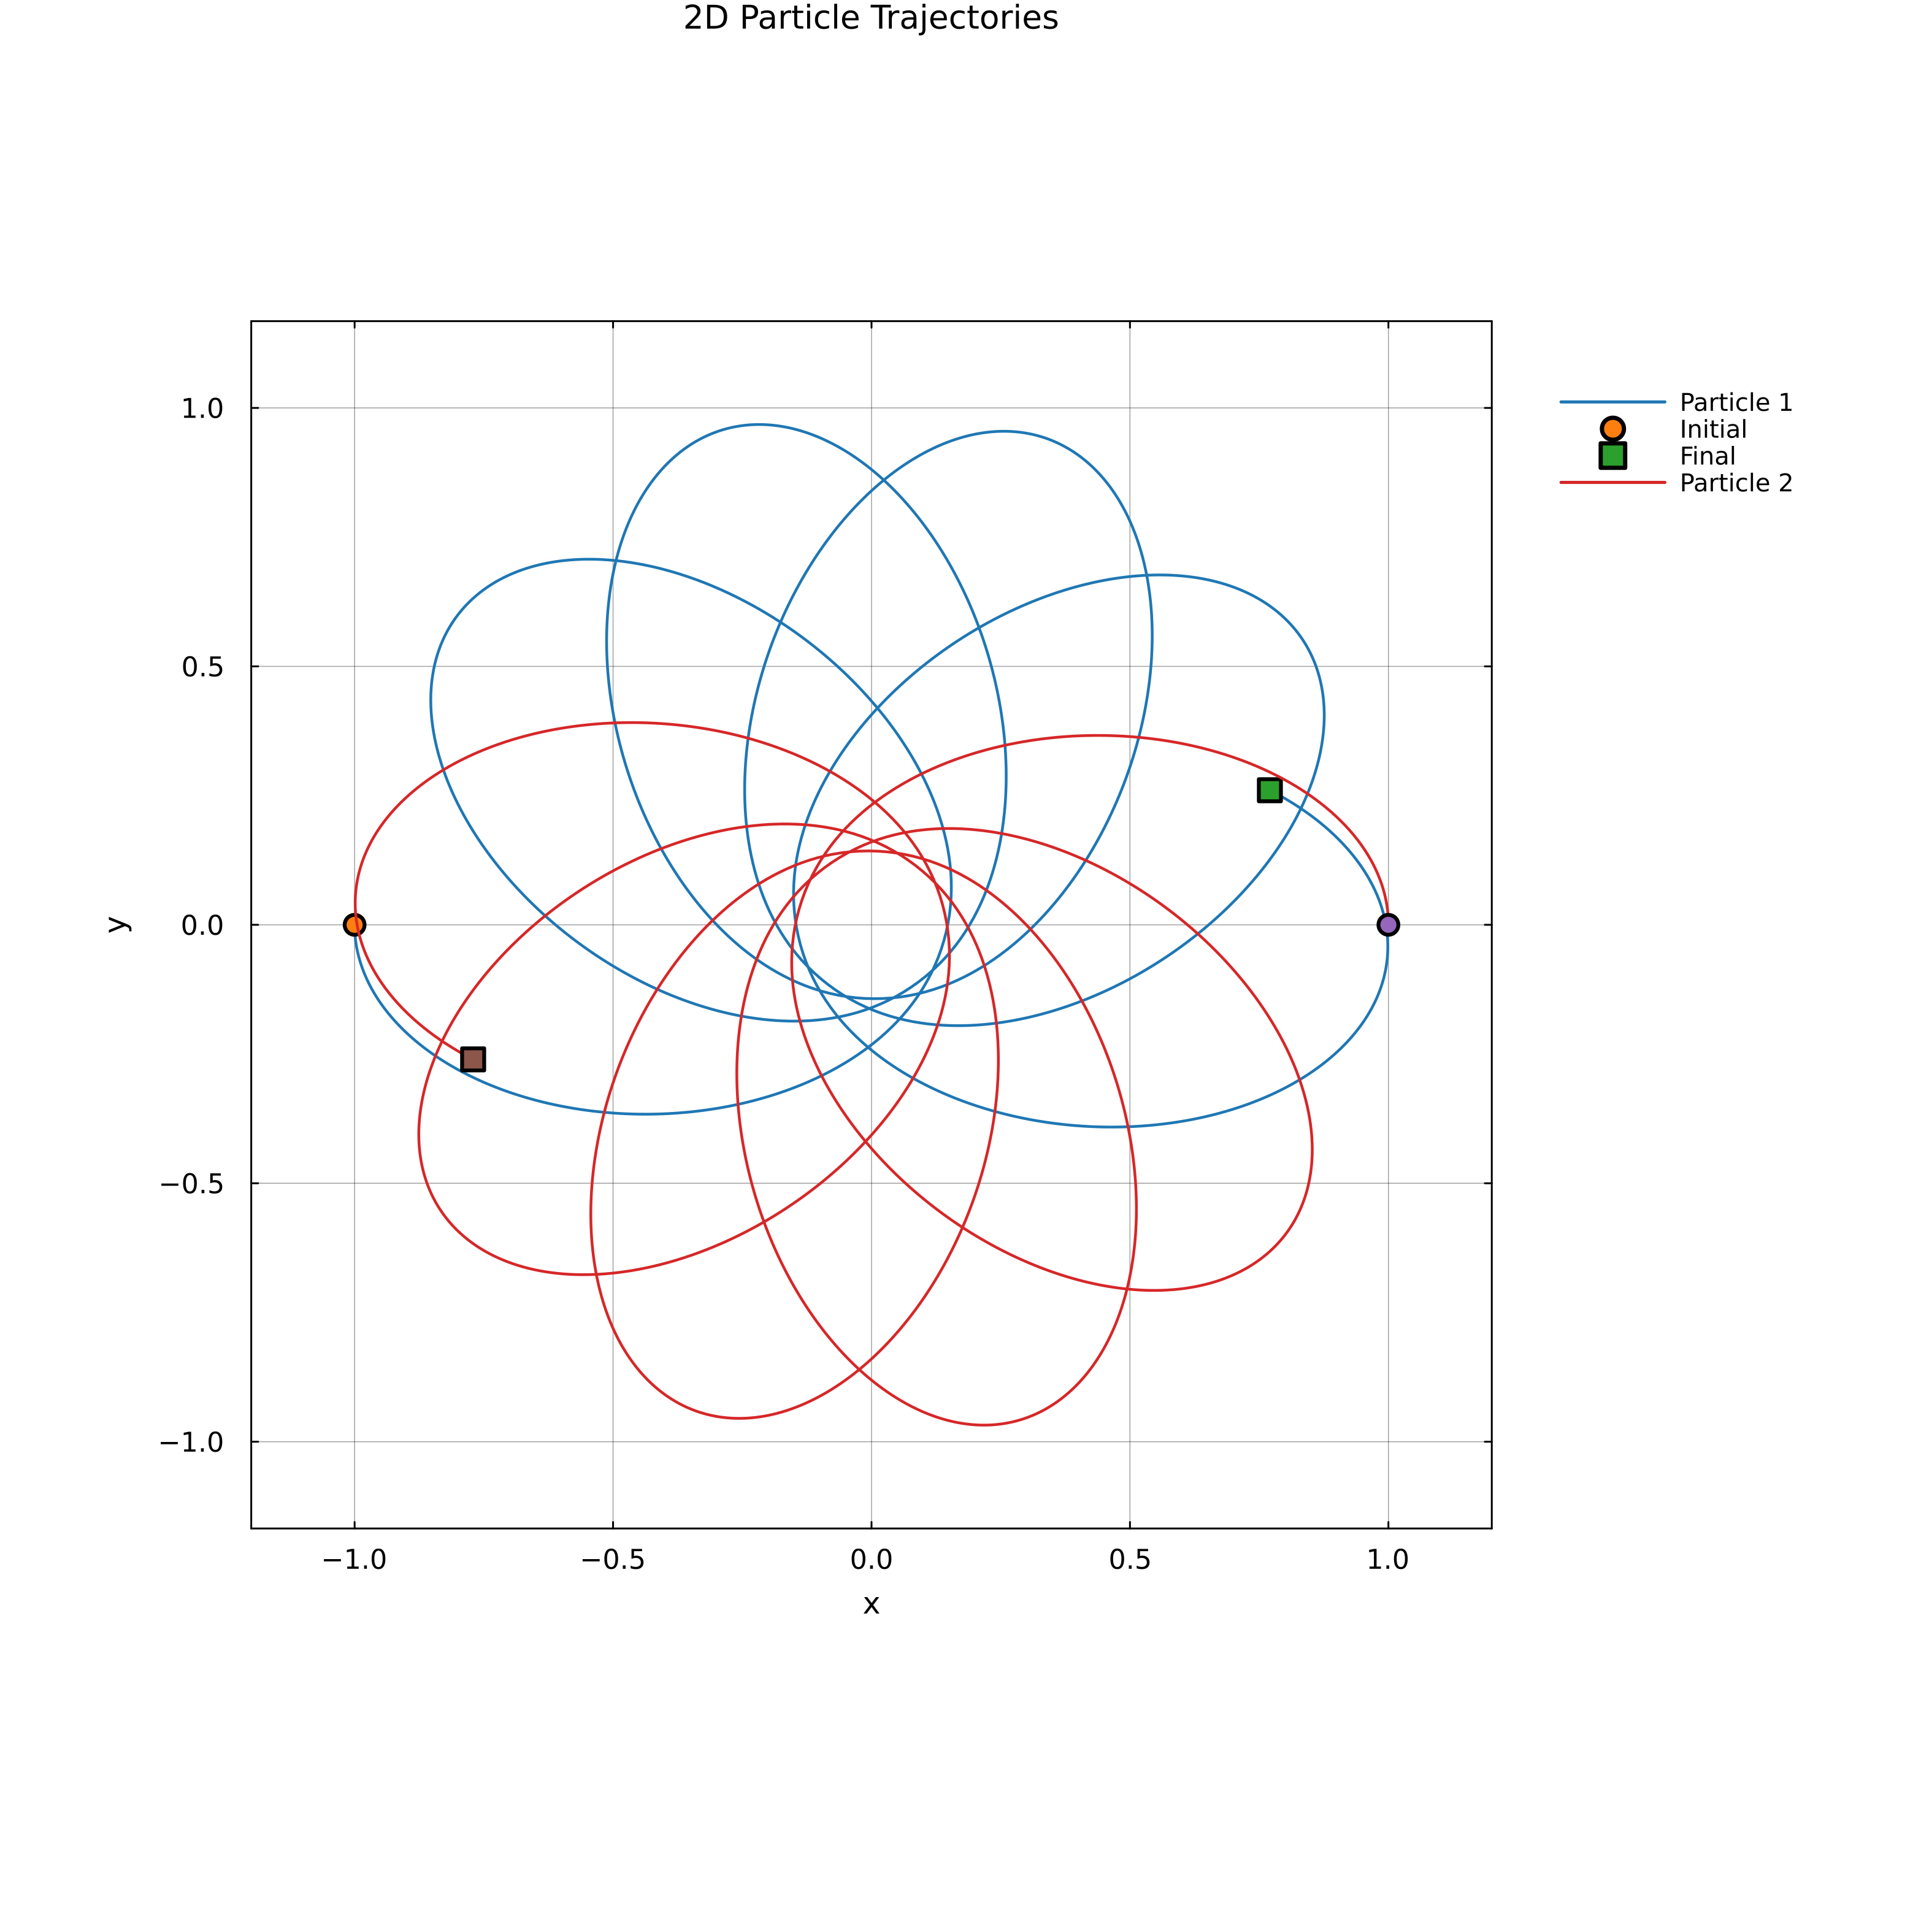

In [10]:
traj = compute_trajectory_data(sol, 2, 2; stride=10)
plot_trajectories(traj)

## 6. Energy Conservation

Verify symplectic integration preserves energy.

In [11]:
# Energy analysis - automatic using Weber Hamiltonian
energy = compute_energy_timeseries(sol; stride=10)

println("Statistics:")
println("  Max local error: ", @sprintf("%.2e", energy.statistics.local_error_max))
println("  Max global error: ", @sprintf("%.2e%%", energy.statistics.global_error_percent_max))
println("  Hamiltonian validation: ", @sprintf("%.2e", maximum(energy.hamiltonian_validation_error)))

# Pair-wise energy decomposition
pair = energy.pair_energies[(1, 2)]
println("\nPair (1,2) energy breakdown:")
println("  Coulomb term range: ", extrema(pair.coulomb_term))
println("  Velocity term range: ", extrema(pair.velocity_term))
println("  Radial velocity range: ", extrema(pair.radial_velocity))

Statistics:
  Max local error: 2.82e-06  Max local error: 2.82e-06
  Max global error: 4.28e-03%
  Hamiltonian validation: 4.44e-16

Pair (1,2) energy breakdown:
  Coulomb term range: (-3.4999150835670045, -0.5)
  Velocity term range: (0.0, 0.12076249894329066)
  Radial velocity range: (-1.3454477248913033, 1.3454514255034504)


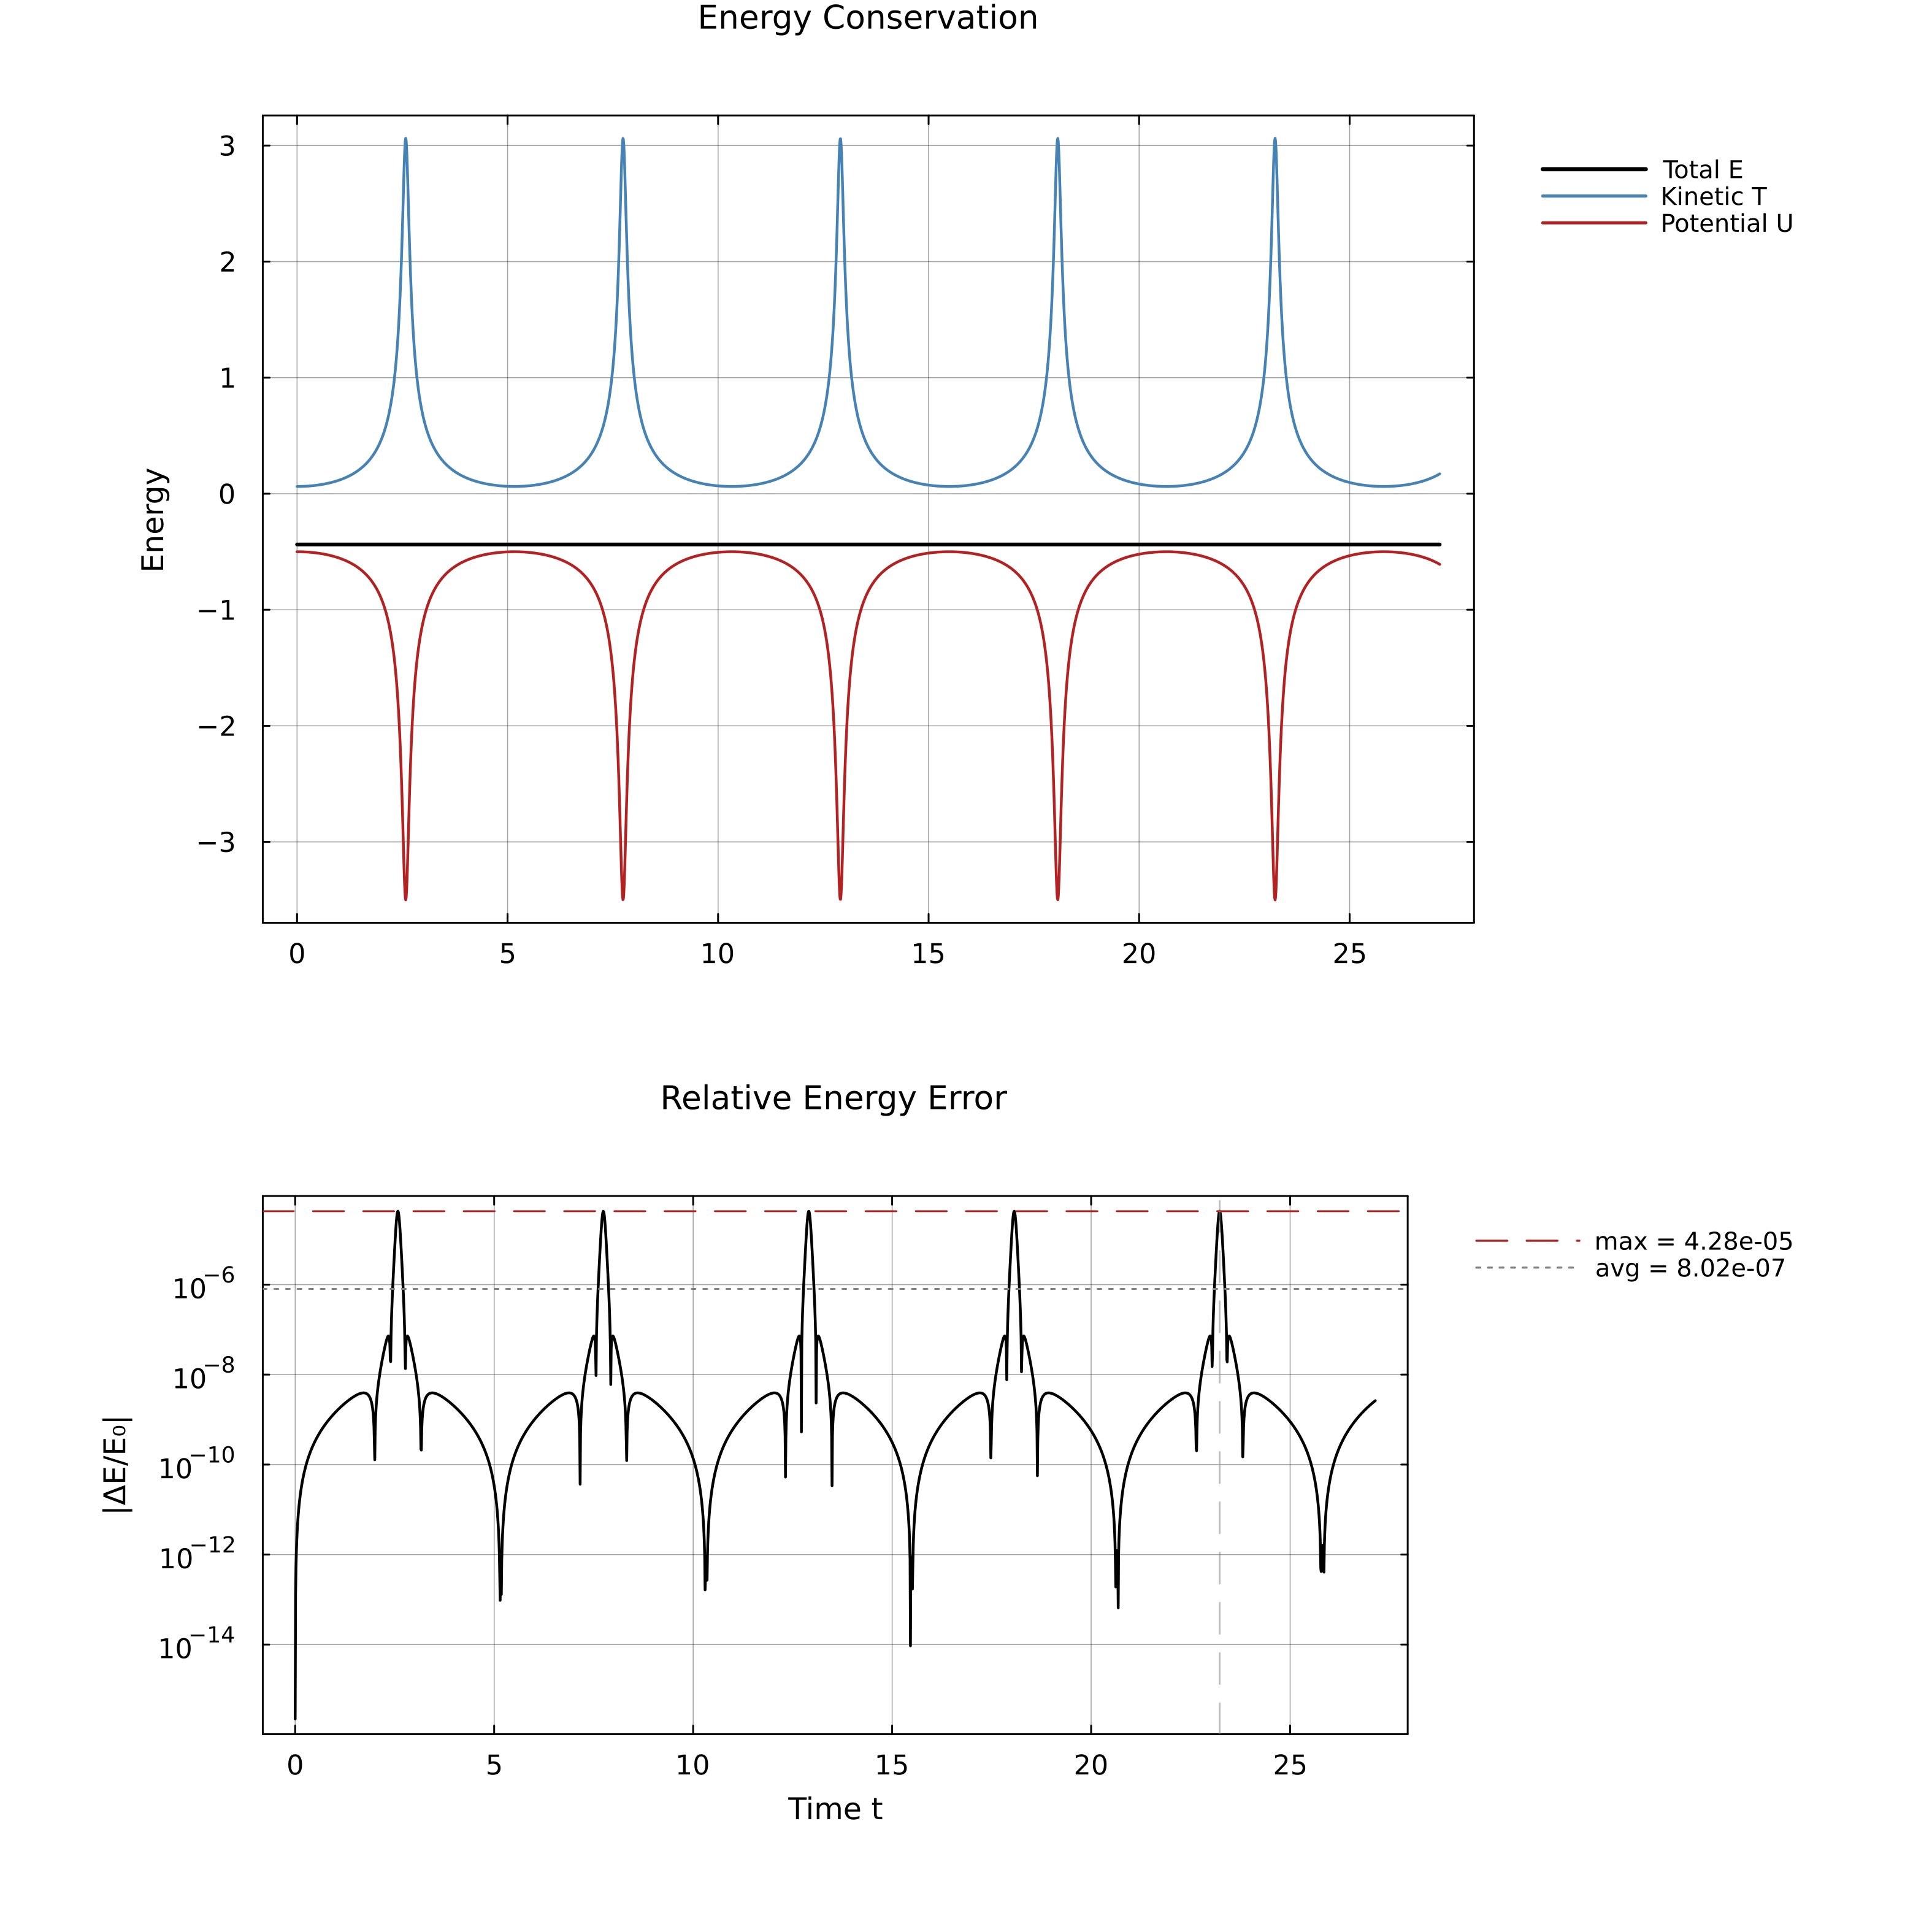

In [12]:
plot_energy(energy)

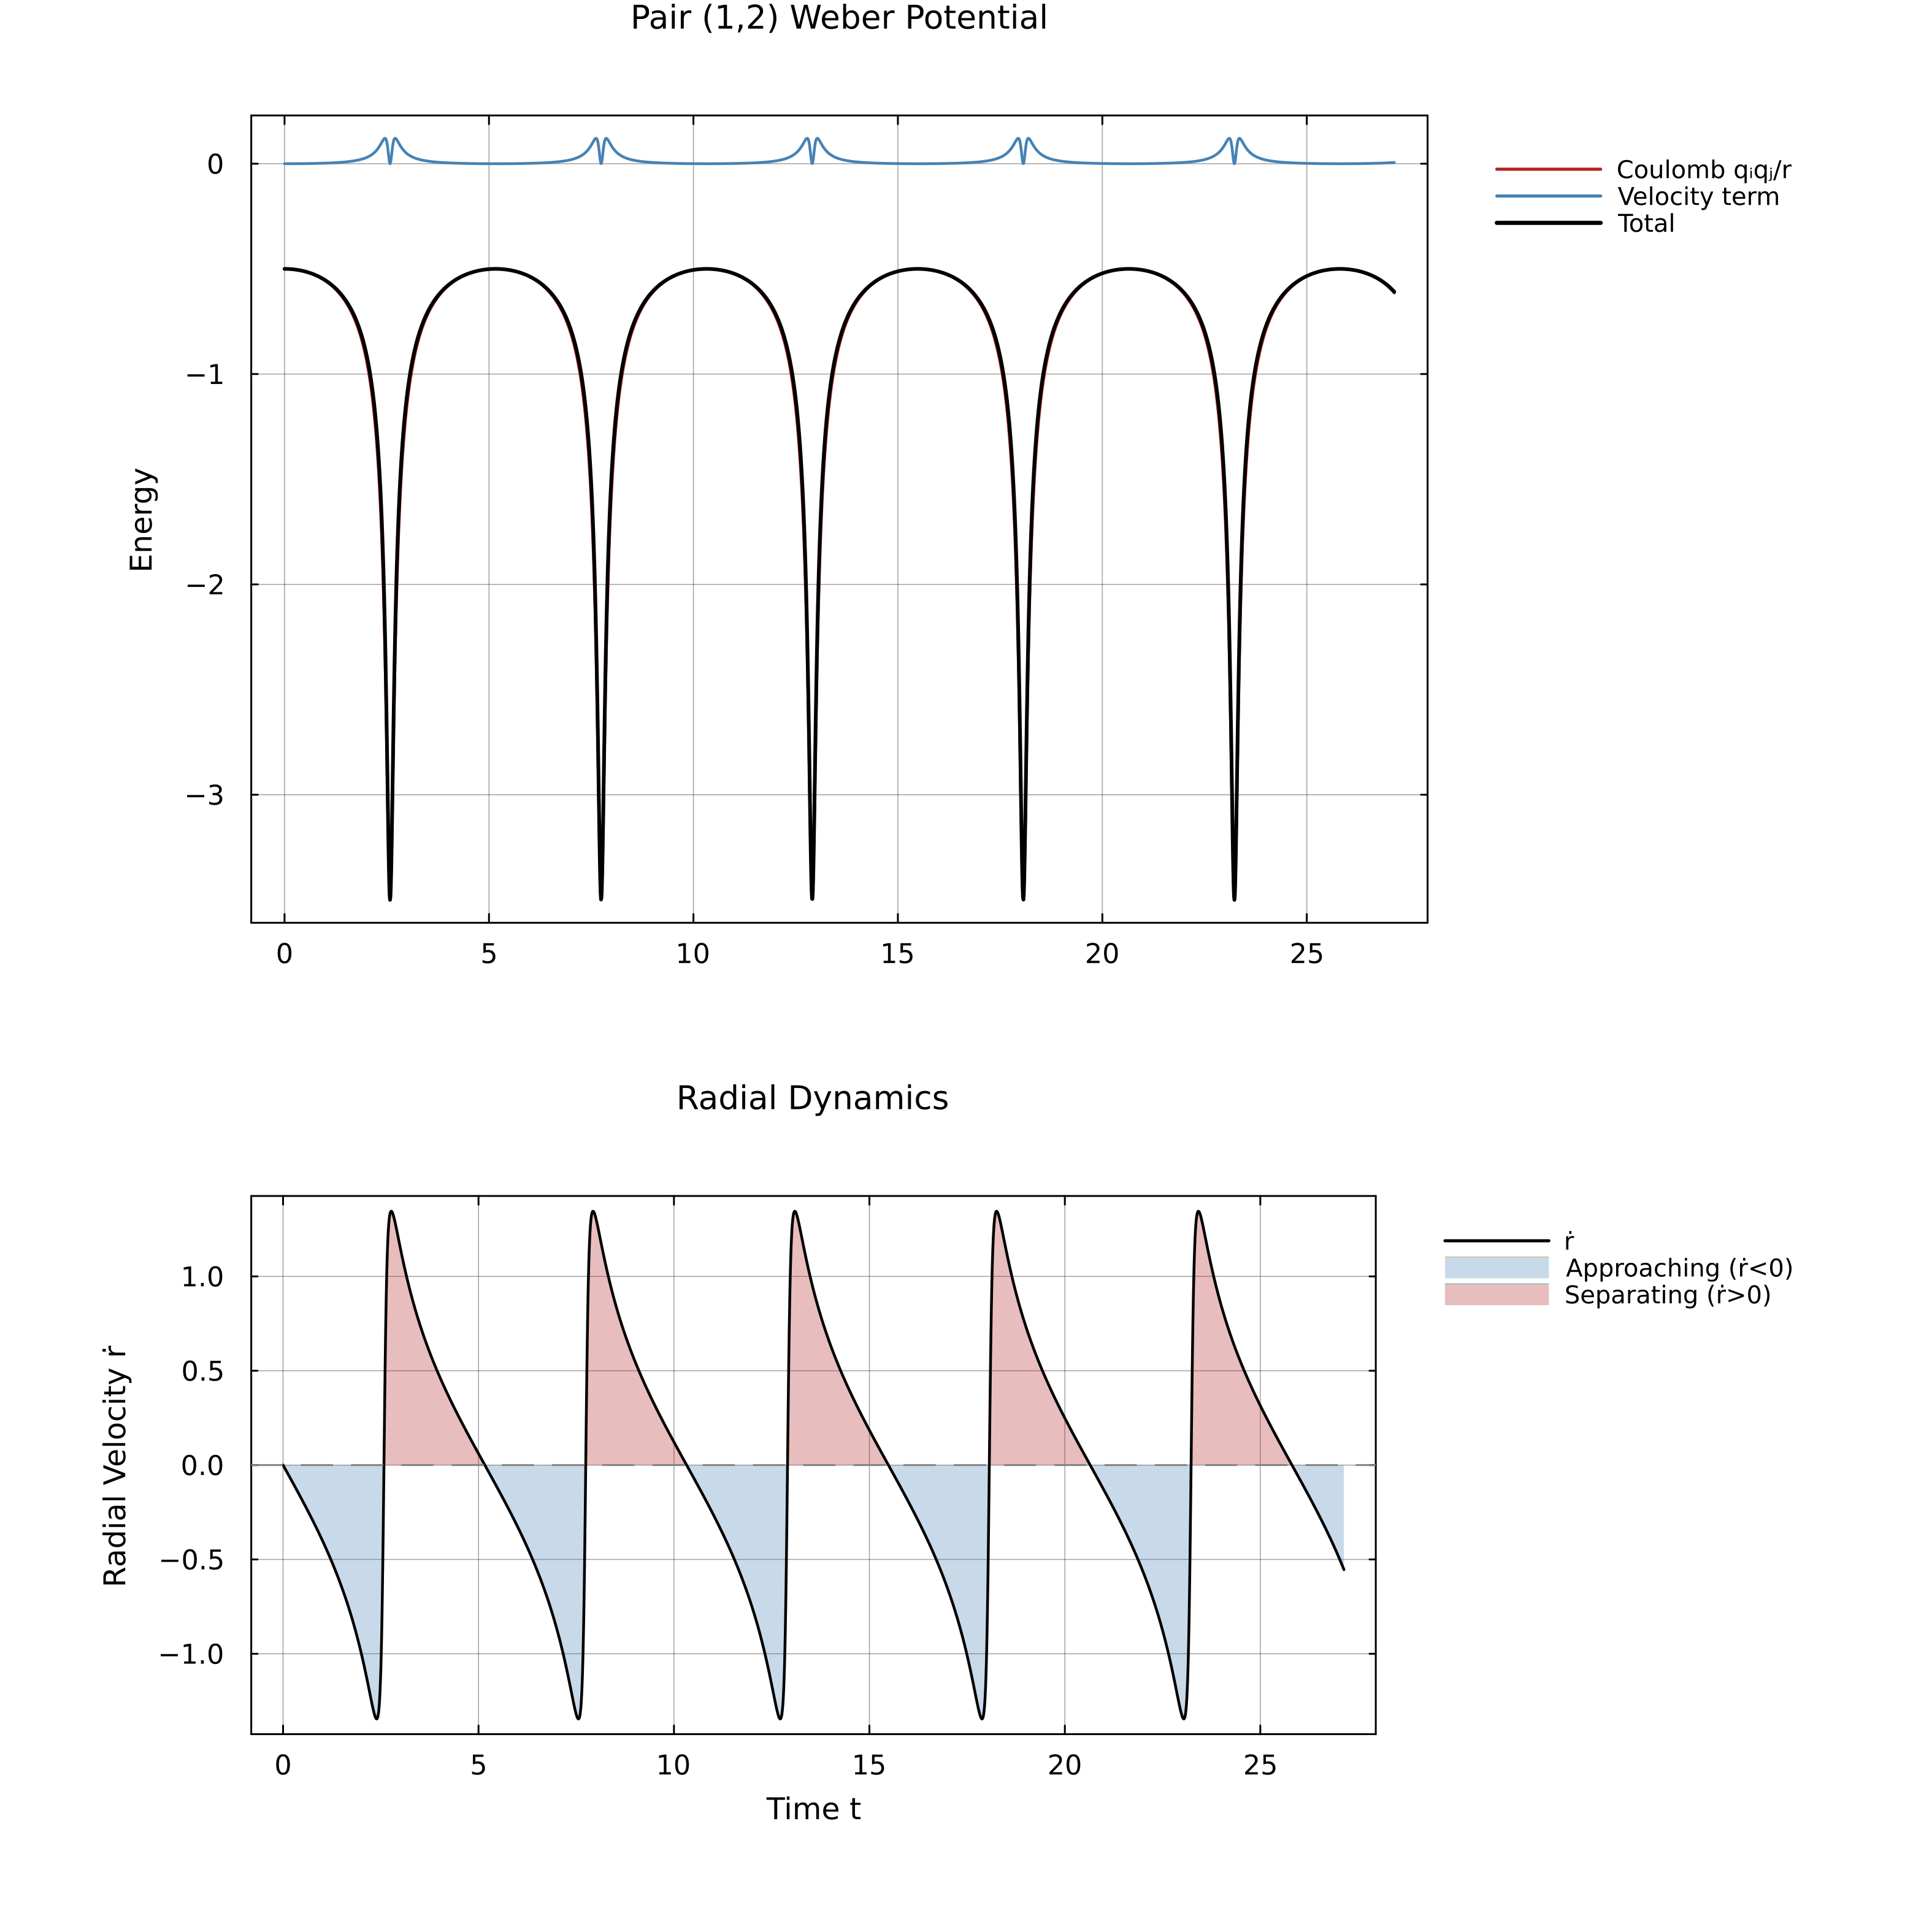

In [13]:
# Pair-wise energy decomposition
plot_pair_energy(energy, (1, 2))

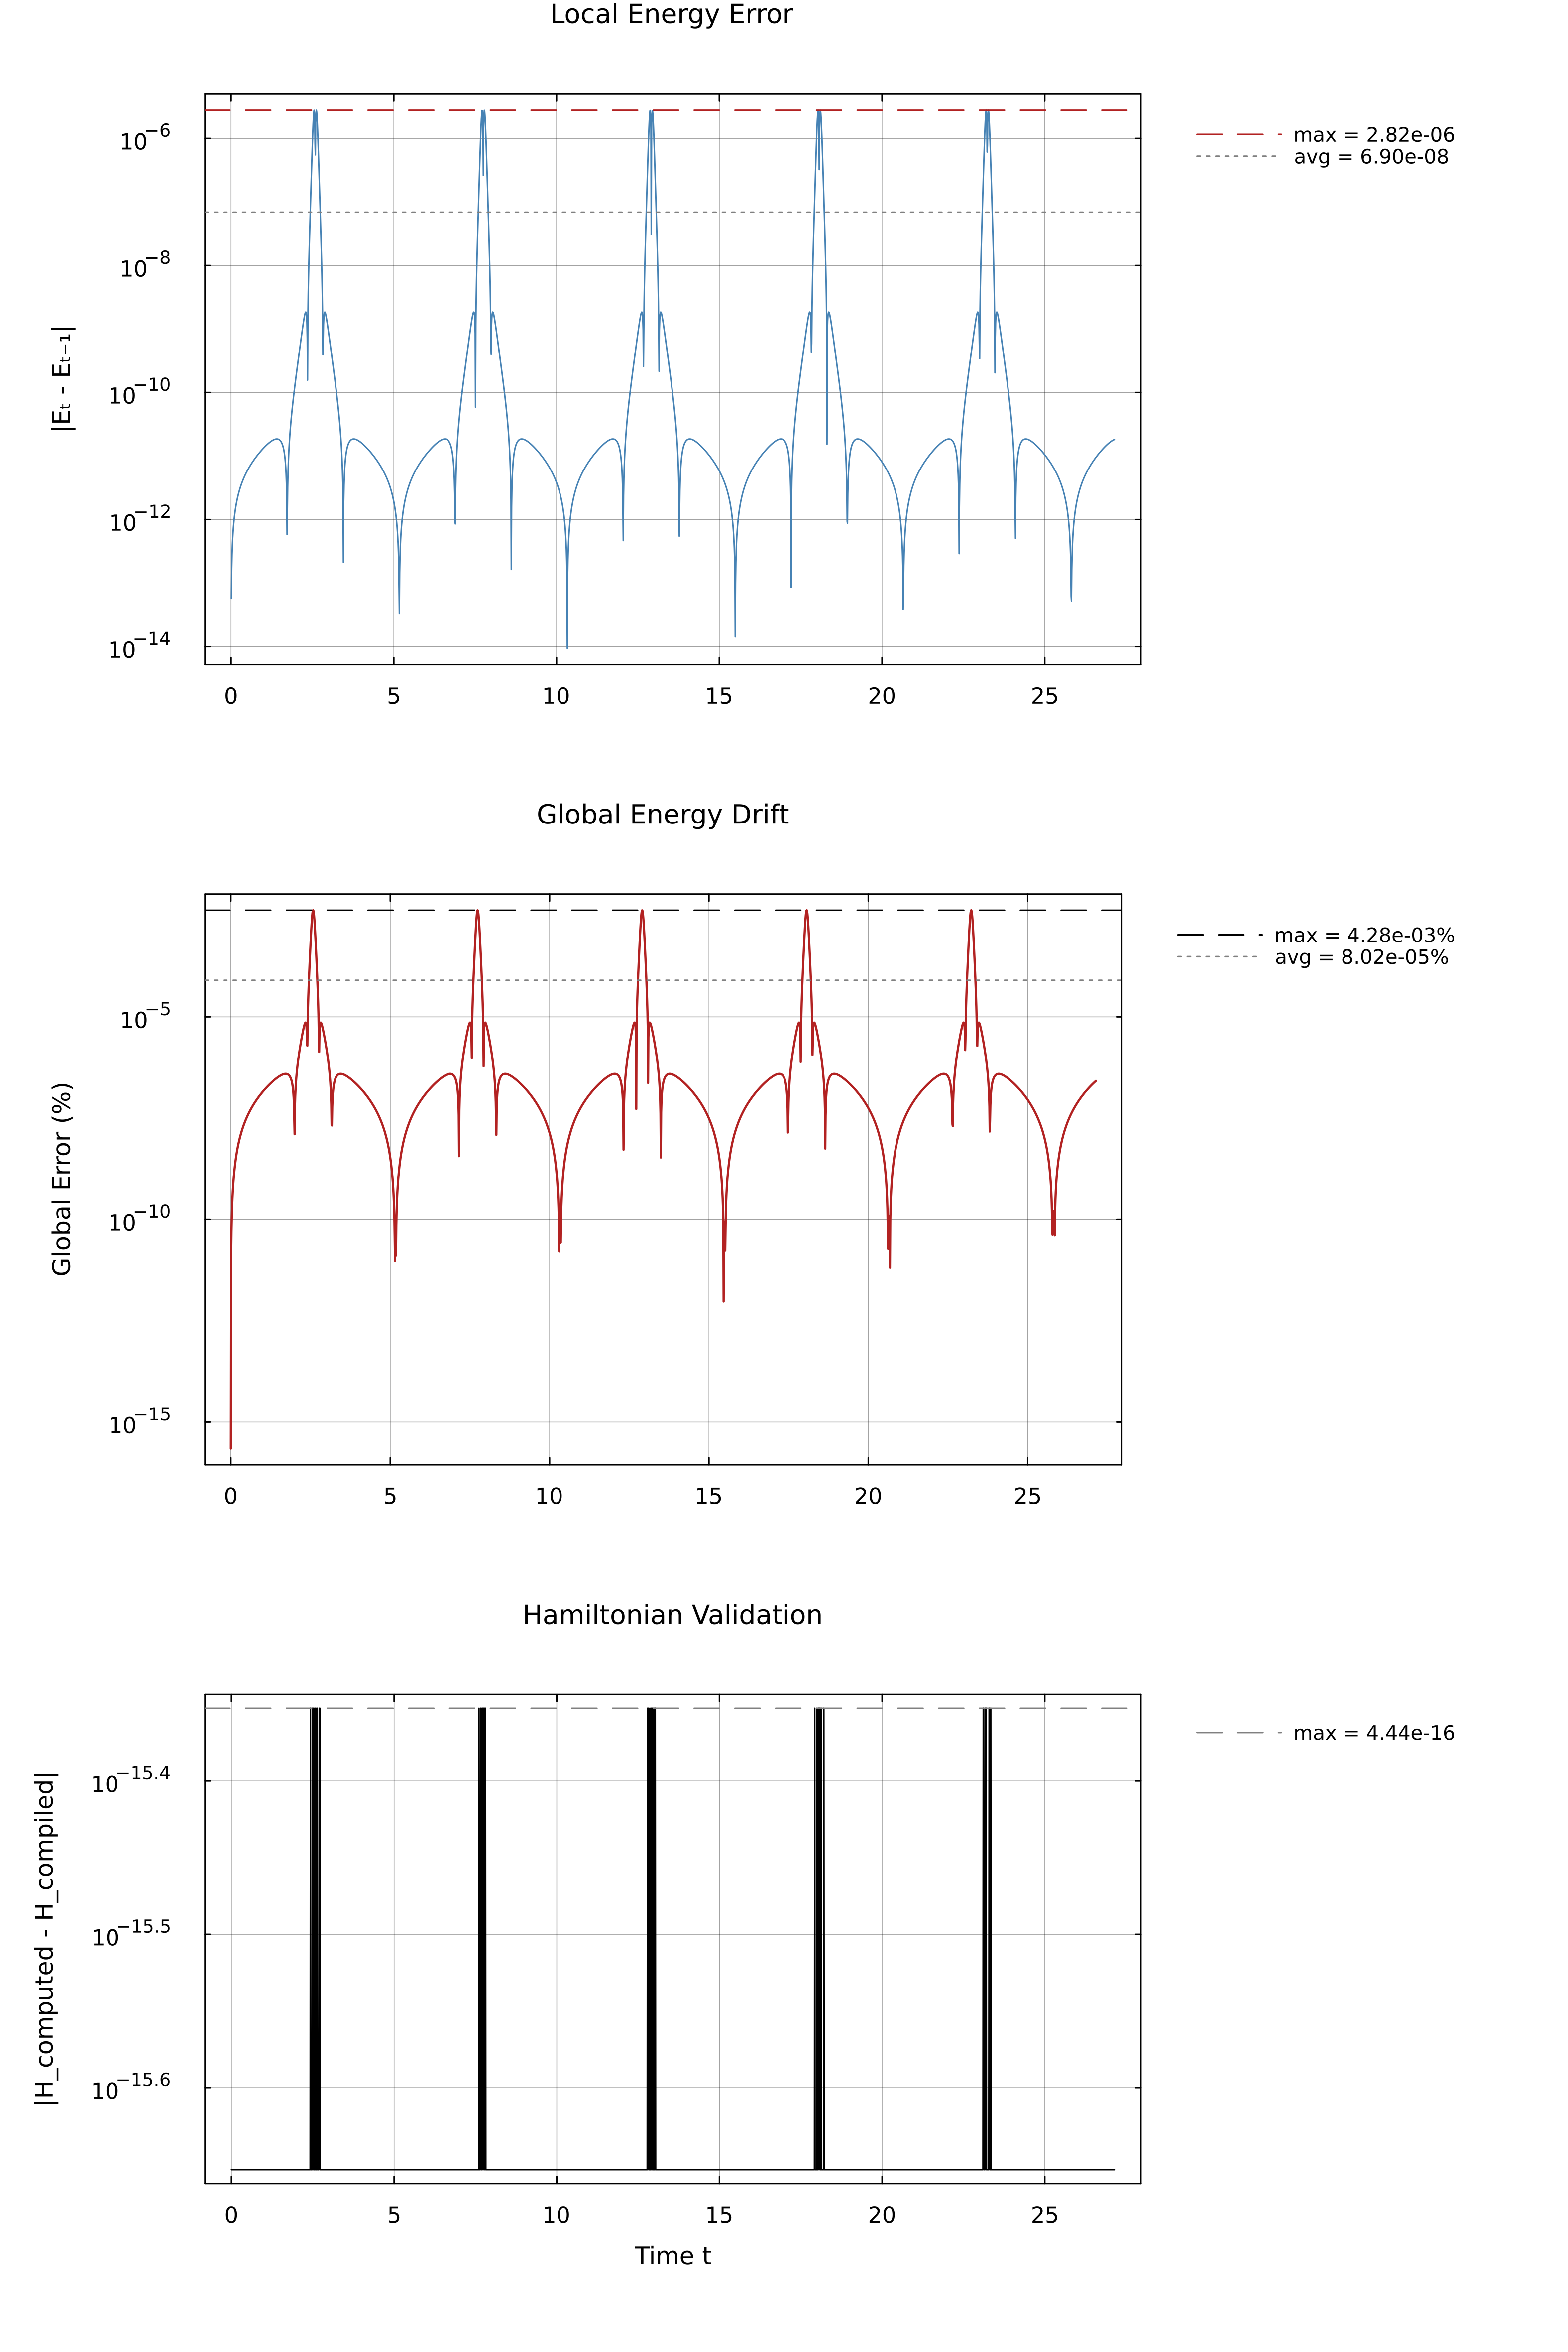

In [14]:
# Comprehensive error analysis
plot_energy_errors(energy)

## 7. Force Analysis

Compute Weber force decomposition for a particle pair. The force is shown in both vector form and radial form, decomposed into Coulomb and velocity-dependent terms.

Force statistics:
  Min: 2.3828e-01
  Max: 1.6313e+01
  Mean: 1.0970e+00
  Range: 1.6074e+01


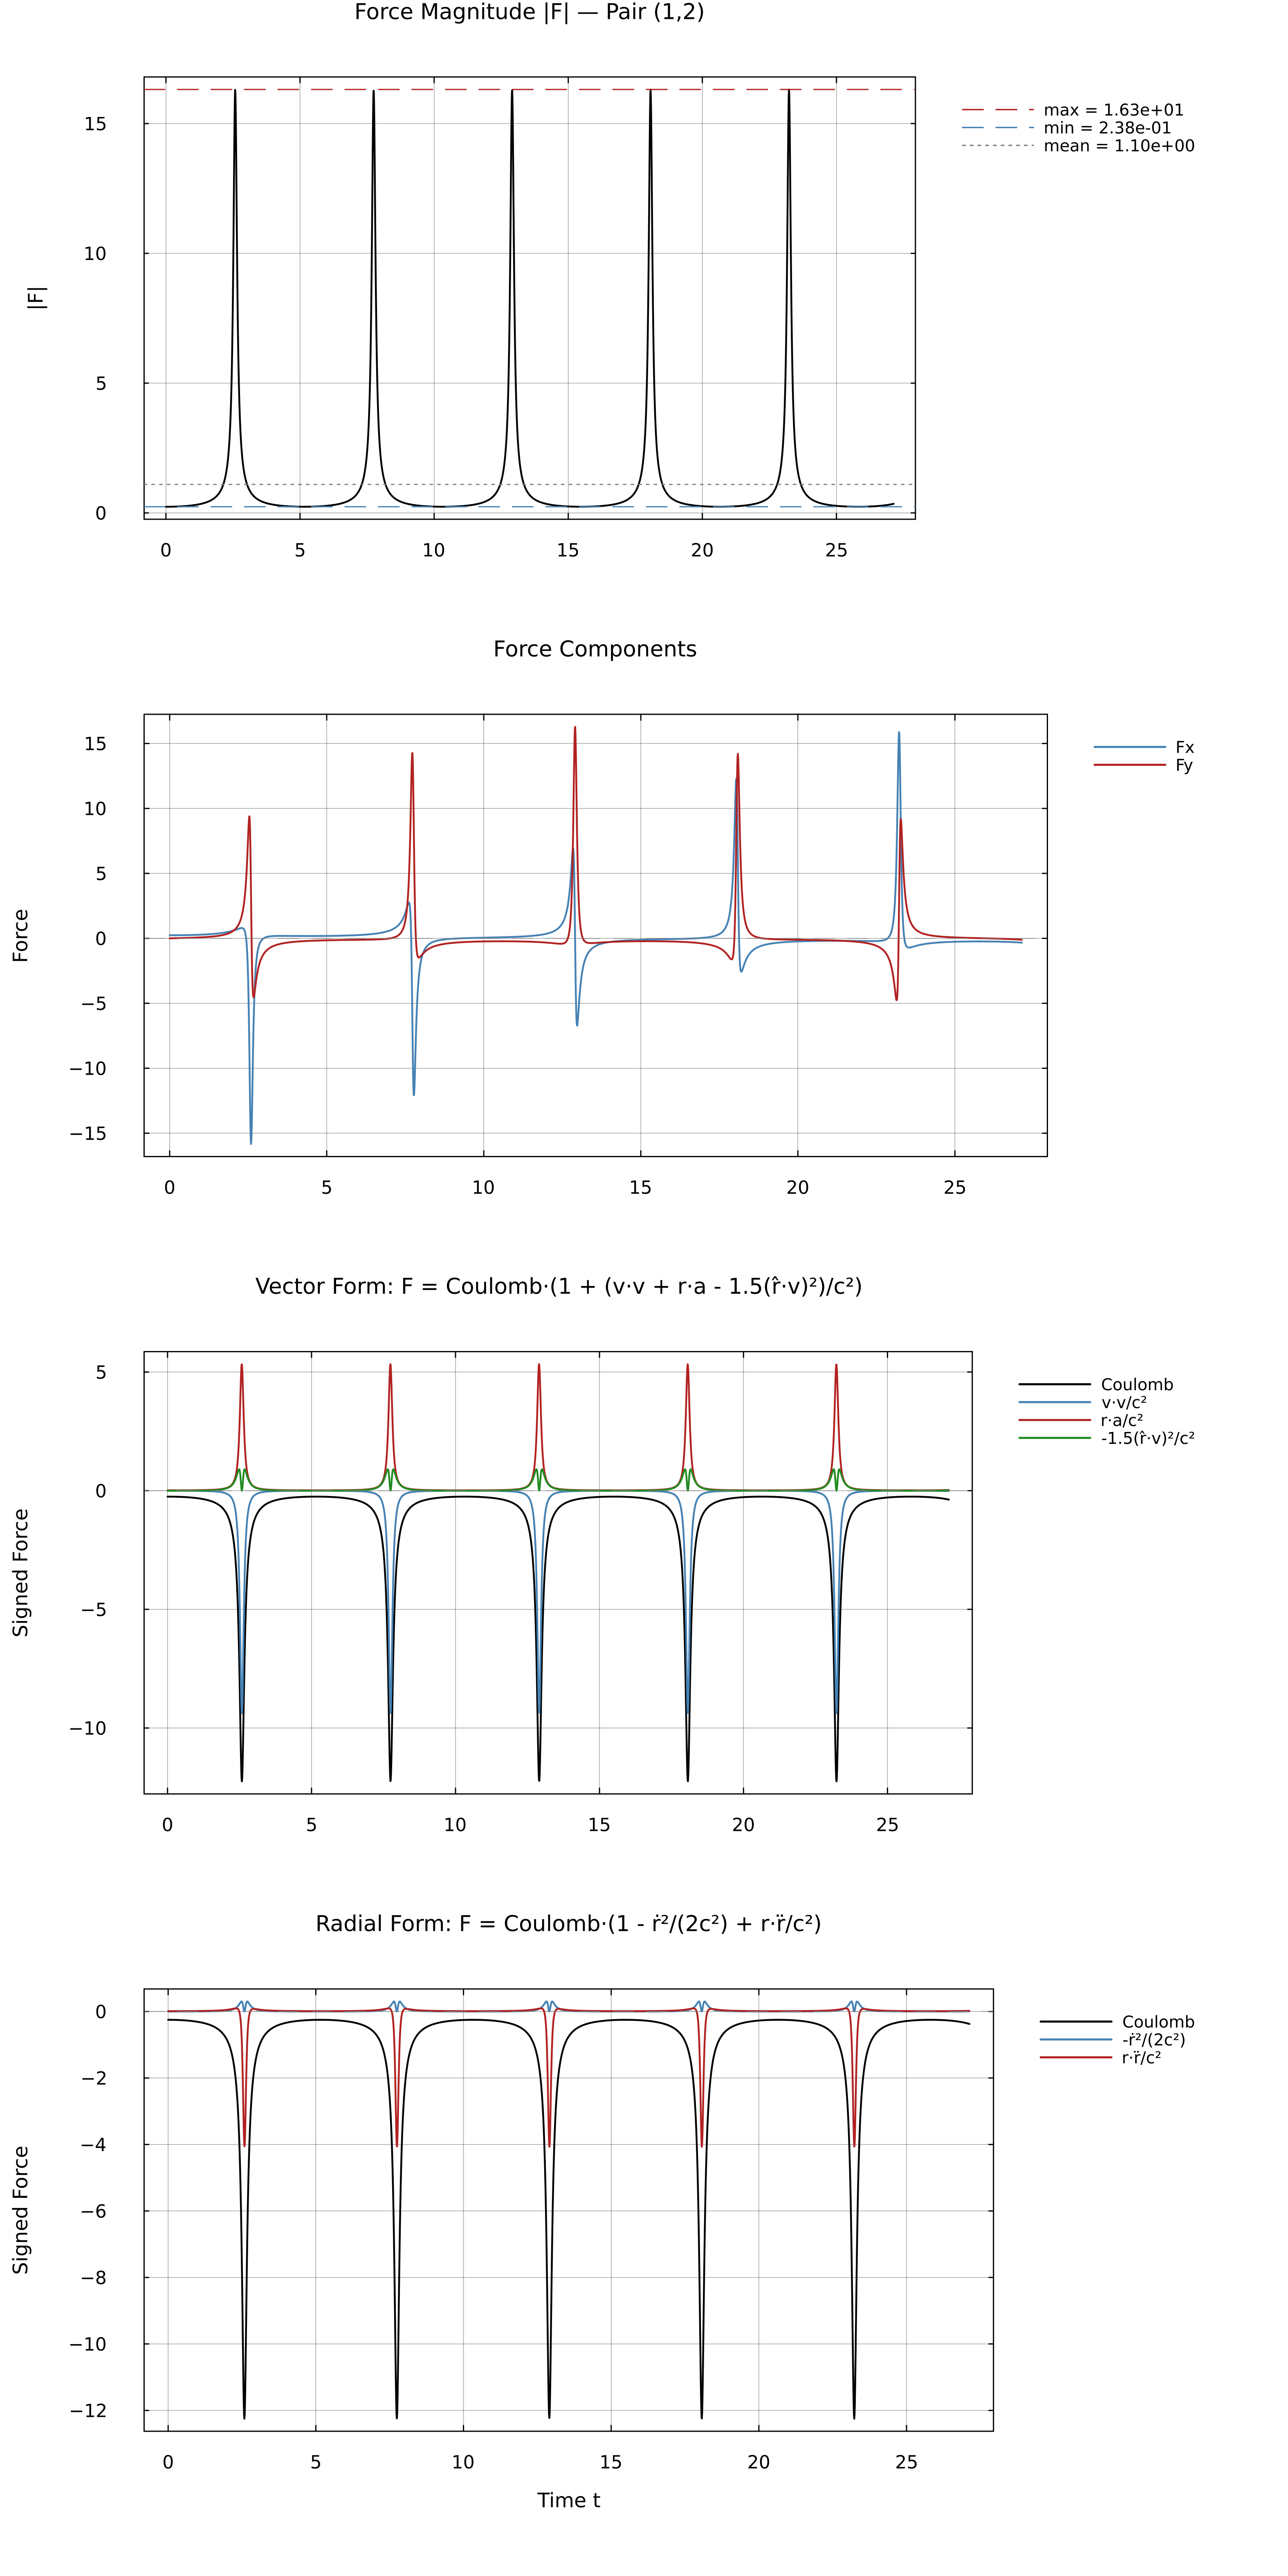

In [15]:
forces = compute_pair_force_timeseries(sol, (1, 2), 2, 2, [m1, m2], [q1, q2], c; stride=10)

println("Force statistics:")
println("  Min: ", @sprintf("%.4e", forces.stats.min))
println("  Max: ", @sprintf("%.4e", forces.stats.max))
println("  Mean: ", @sprintf("%.4e", forces.stats.mean))
println("  Range: ", @sprintf("%.4e", forces.stats.range))

plot_pair_forces(forces)

## 8. Phase Space

Analyze the relative motion in $(r, \dot{r})$ phase space.

Min separation: 0.286
Max separation: 2.0


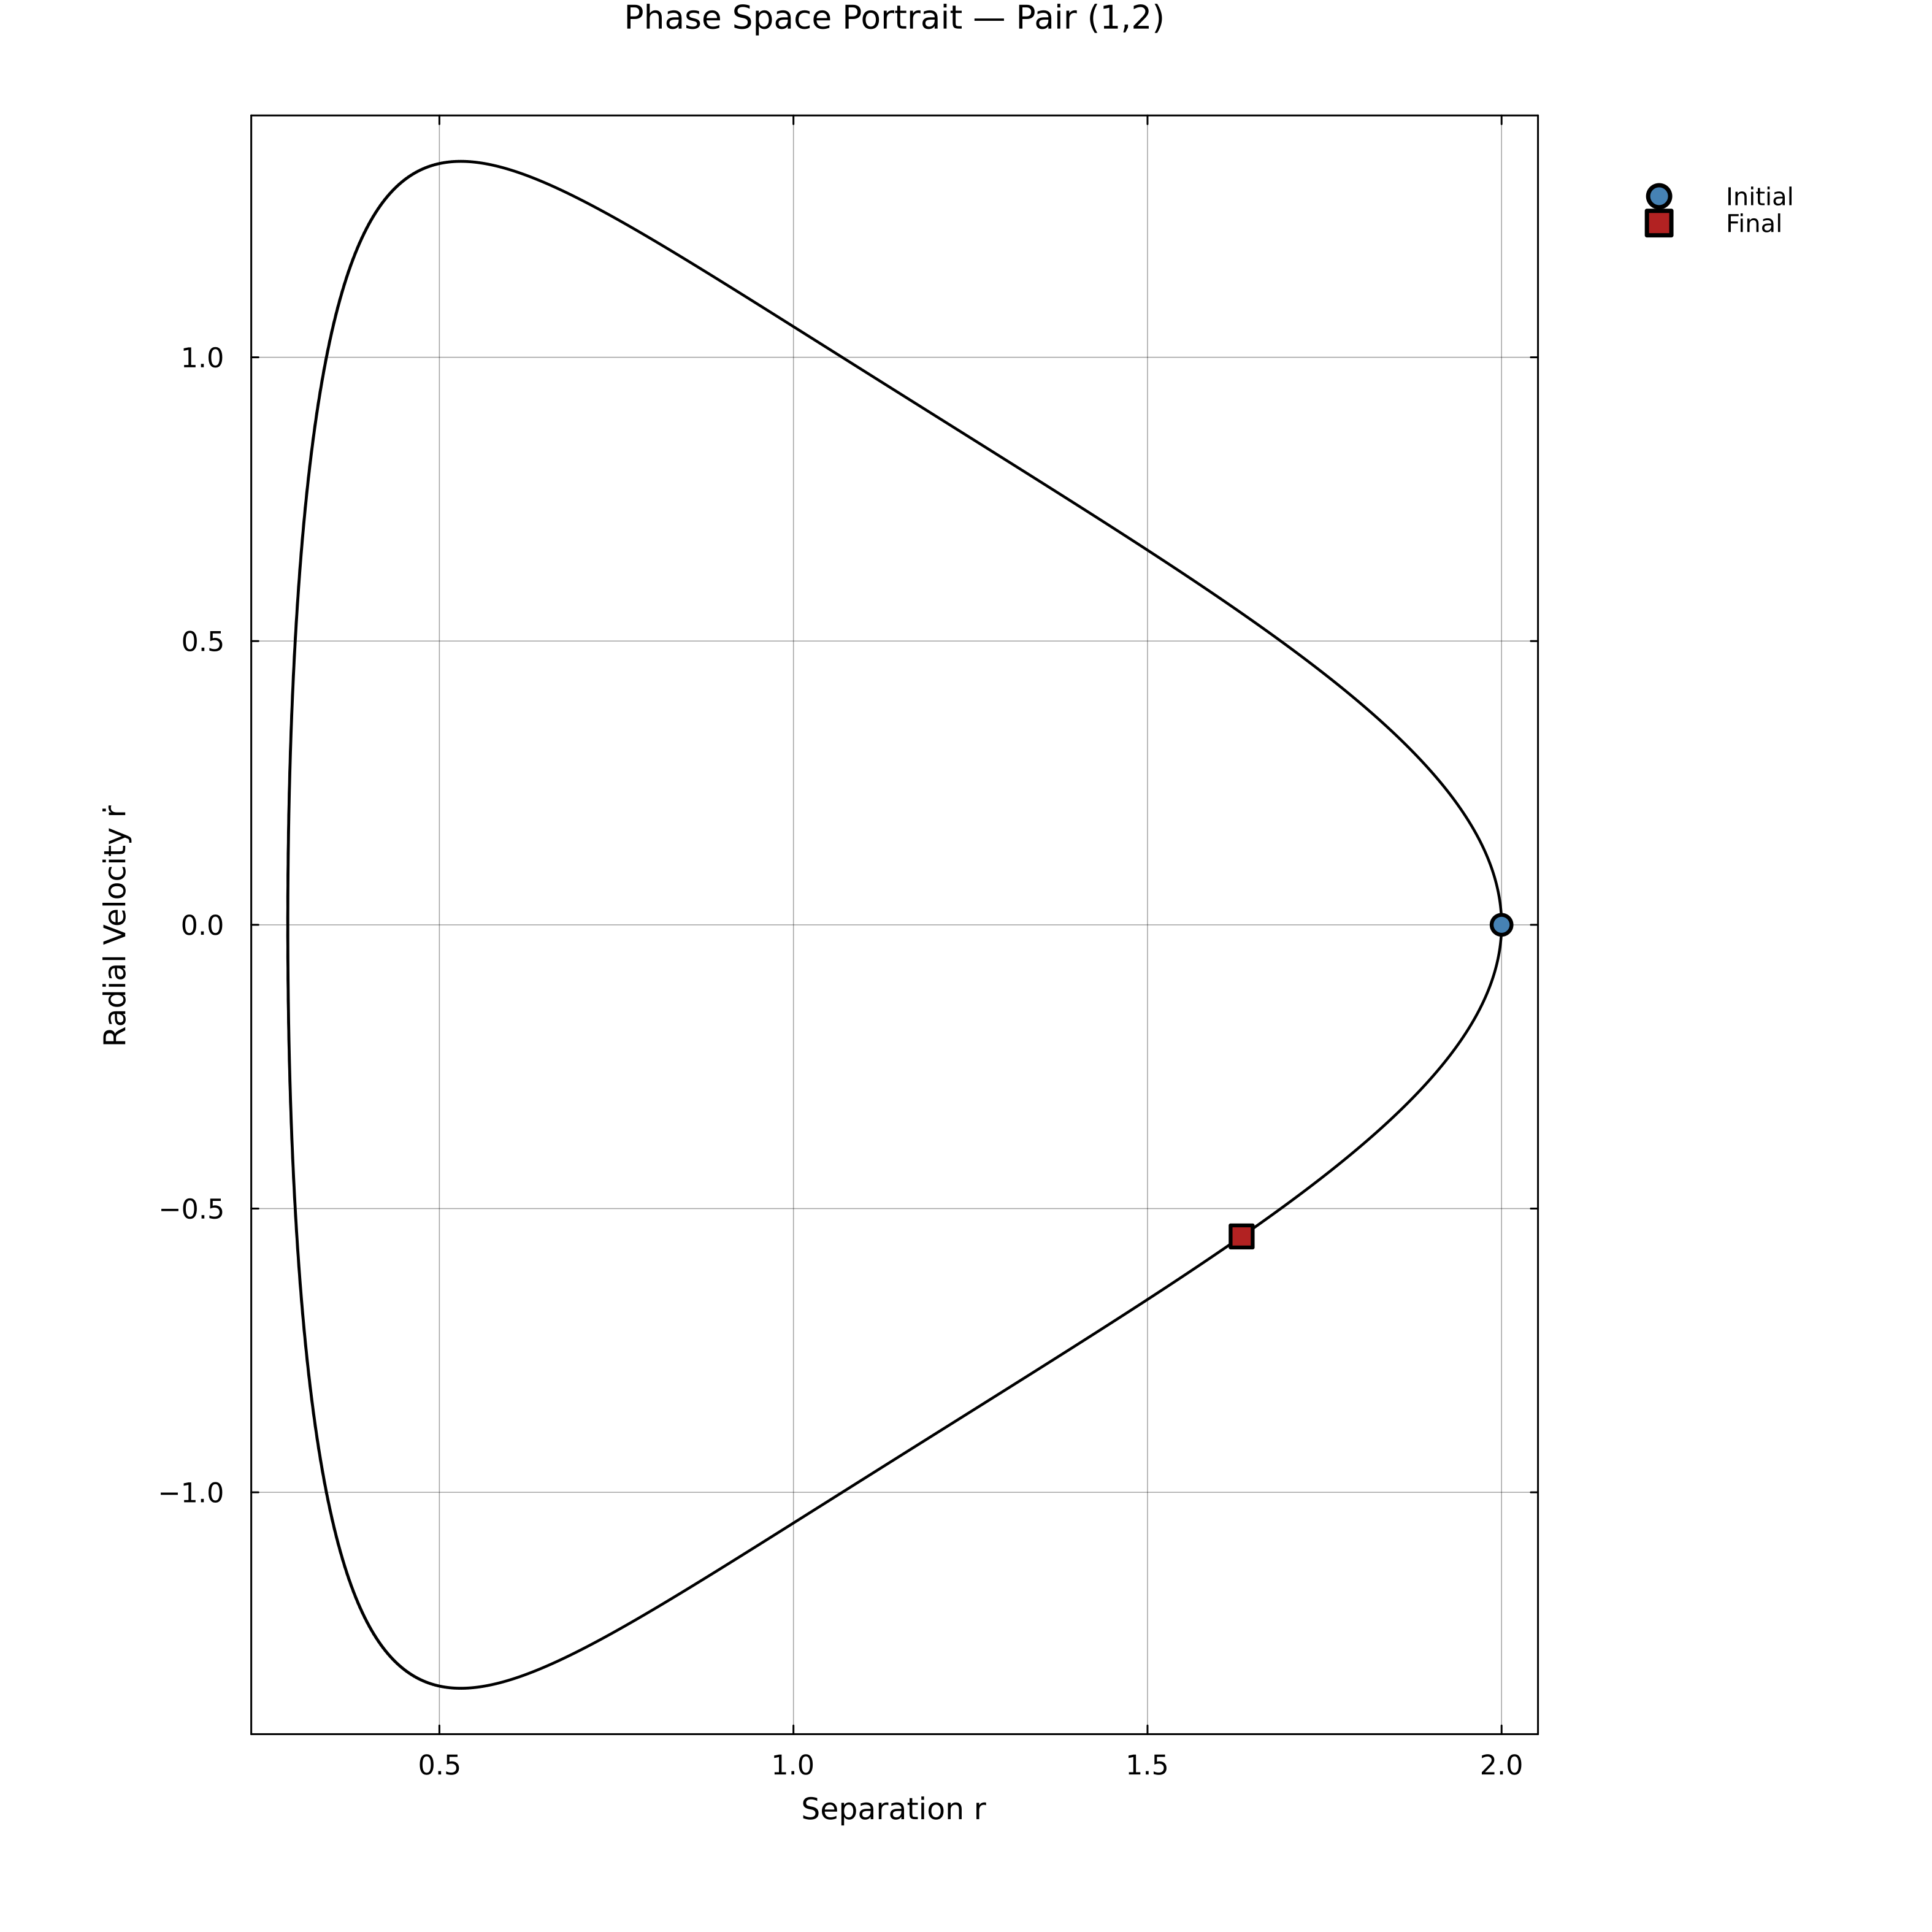

In [16]:
# Phase space is embedded in force data (no redundant computation)
ps = forces.phase_space

println("Min separation: ", round(minimum(ps.separation_distance), digits=3))
println("Max separation: ", round(maximum(ps.separation_distance), digits=3))

plot_phase_space(forces)

## 9. Momentum Conservation

`plot_momentum_errors` plots drift of linear `‖ΔP‖` and angular `|ΔLz|`
momentum from their initial values, on stacked log-scale panels. Each
legend reports the max absolute drift and — when the initial magnitude is
nonzero — the max relative drift `max_t ‖Δ·‖ / ‖·₀‖`.

This canonical setup has `P₀ = 0` (COM frame), so the linear panel shows
absolute drift only; angular momentum `Lz₀ = 1/2` is nonzero and its panel
reports both absolute and relative drift.

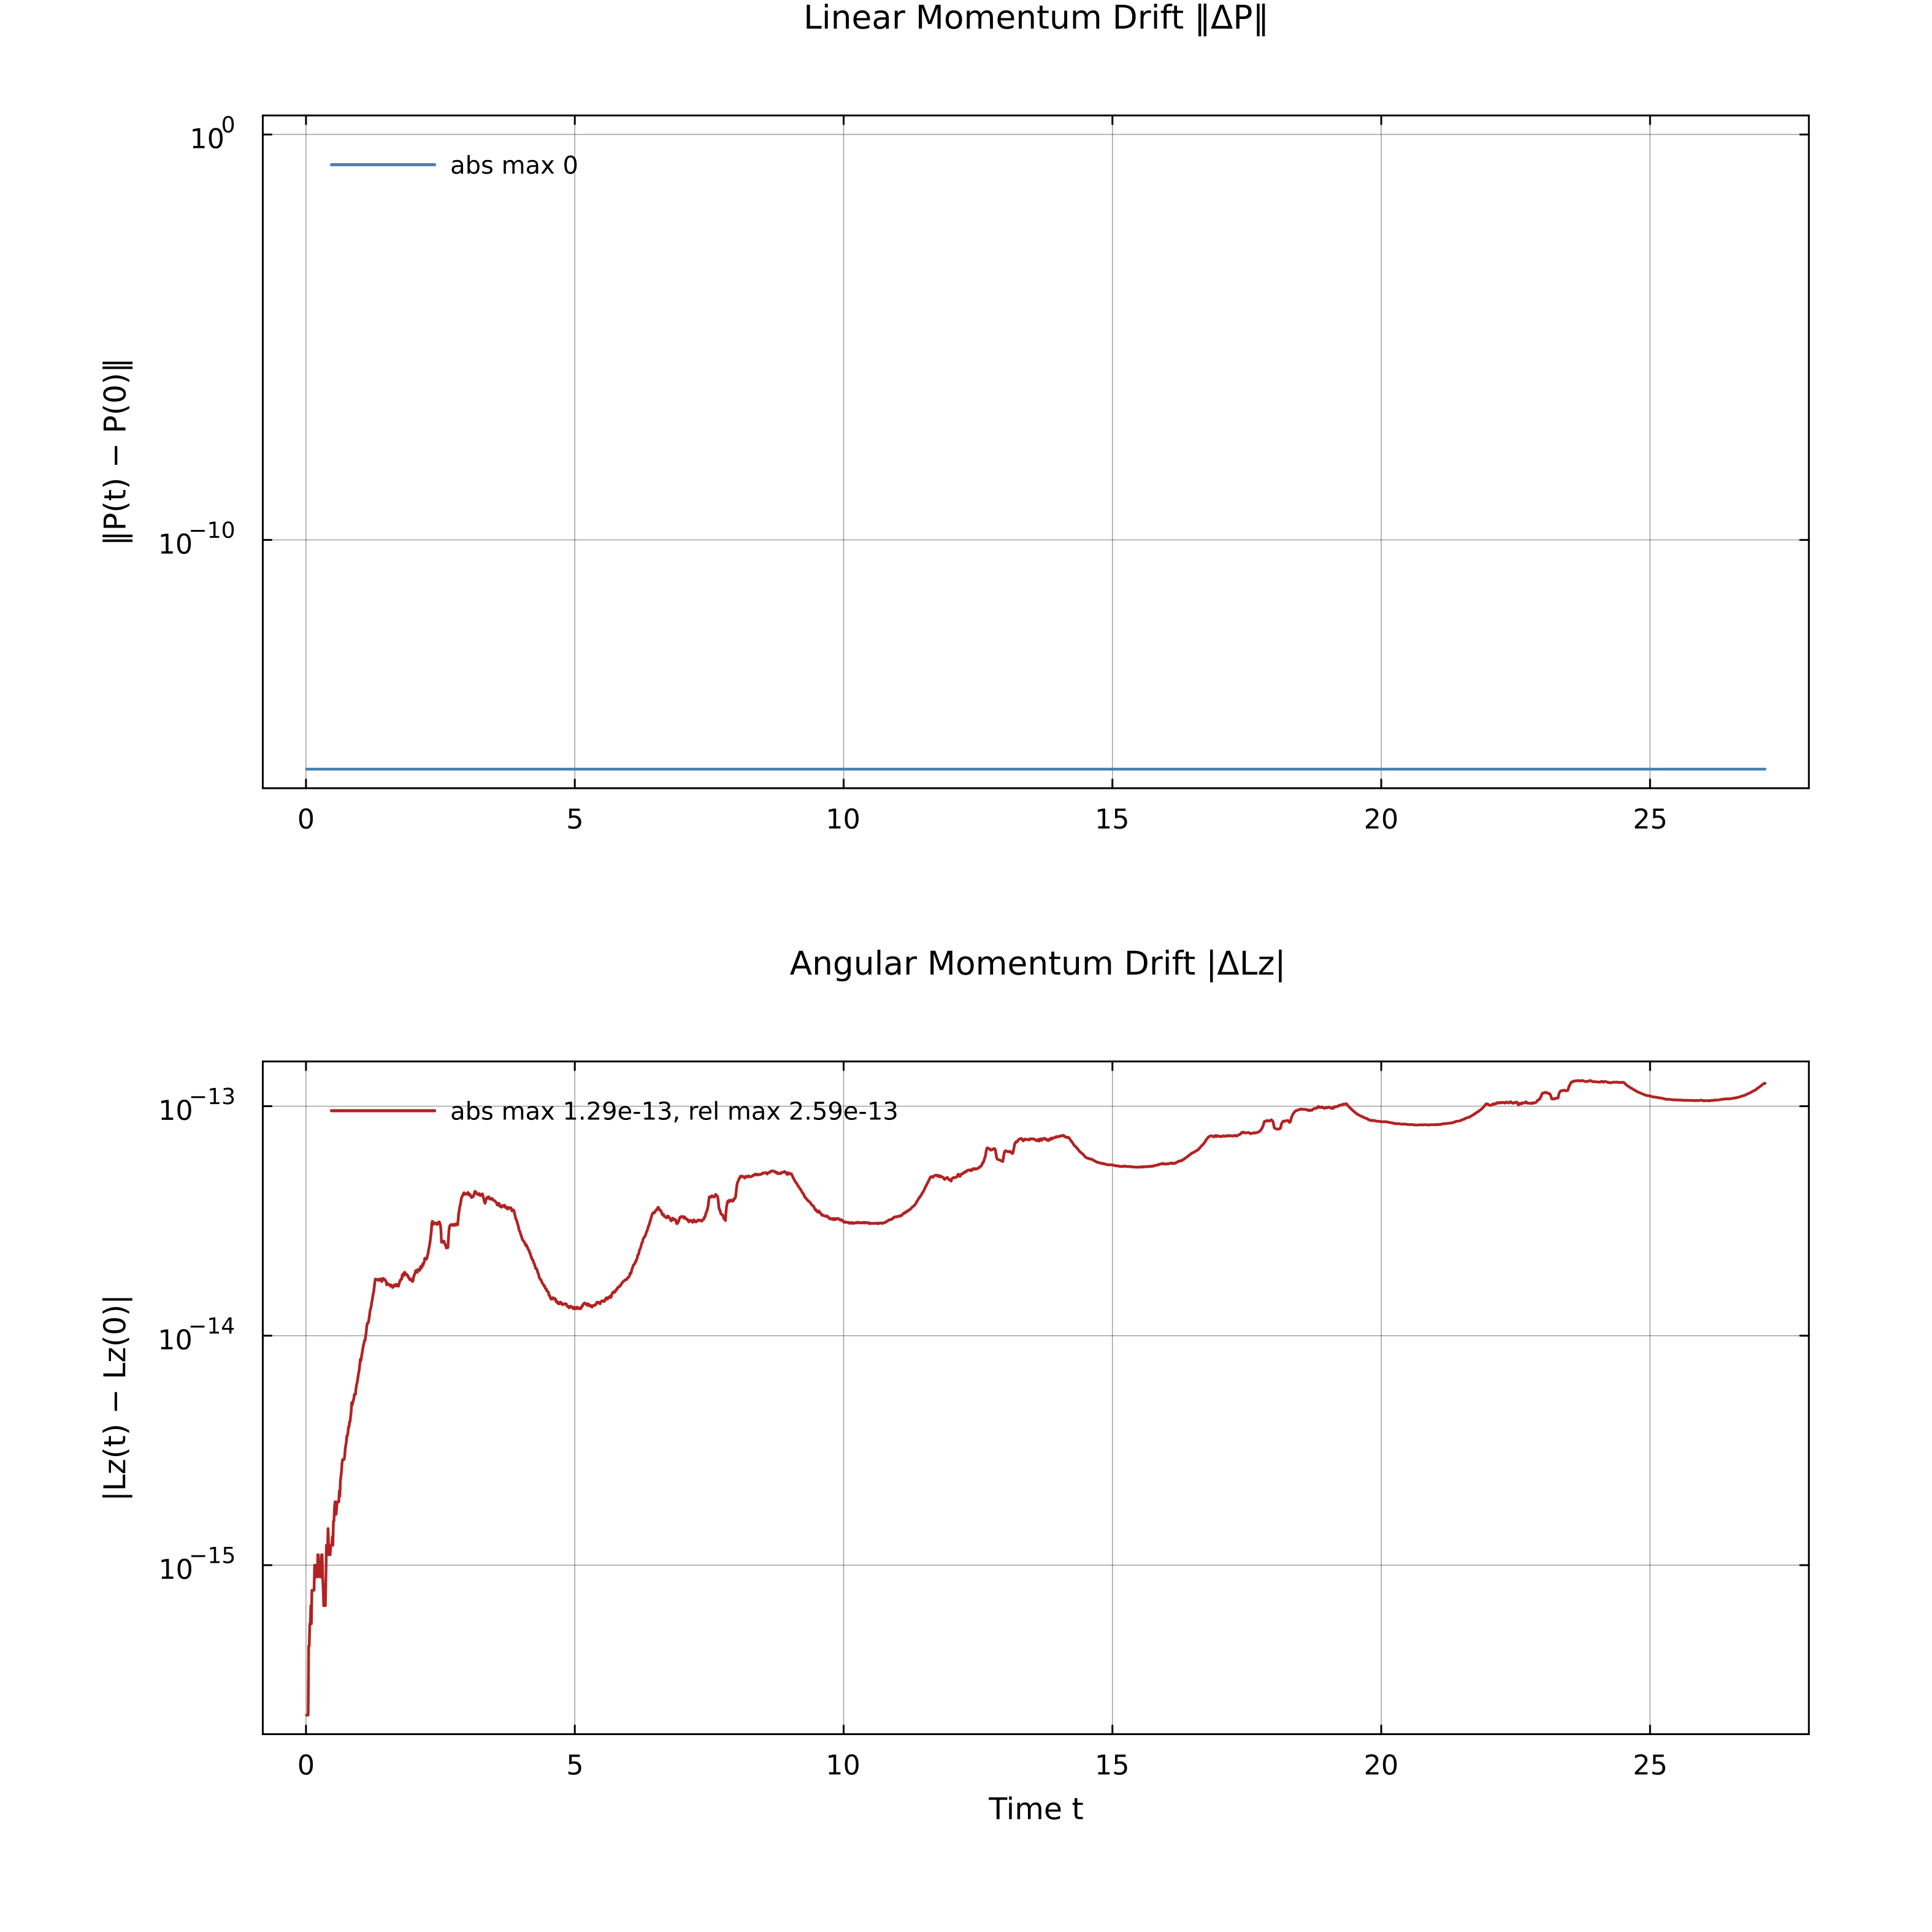

In [17]:
momentum = compute_momentum_timeseries(sol; stride=10)
plot_momentum_errors(momentum)

## API Summary

| Category | Types | Functions |
|----------|-------|-----------|
| **System** | `WeberSystem` | - |
| **Problem** | `WeberProblem` | - |
| **Solution** | `WeberSolution`, `WeberIntegrator` | `solve`, `init`, `step!`, `solve!` |
| **Trajectories** | `TrajectoryData` | `compute_trajectory_data`, `plot_trajectories` |
| **Energy** | `EnergyData`, `PairEnergyData`, `EnergyStatistics` | `compute_energy_timeseries`, `plot_energy`, `plot_pair_energy`, `plot_energy_errors` |
| **Forces + Phase Space** | `PairForceData`, `ForceStatistics`, `PhaseSpaceData` | `compute_pair_force_timeseries`, `plot_pair_forces`, `plot_phase_space` |
| **Momentum** | `MomentumData` | `compute_momentum_timeseries`, `plot_momentum_errors` |

Phase space data is embedded in `PairForceData.phase_space` to avoid redundant computation of `r` and `ṙ`.